In [16]:
"""
=============================================================================
PROBLEM STATEMENT
=============================================================================

You are a Data Scientist at a large e-commerce company. The Growth team
ran a loyalty rewards program that launched on January 1, 2023, targeting all
registered users. The program gave users points for every purchase, redeemable
for discounts. The business wants to know:

  "Did the loyalty program actually cause an increase in weekly revenue per user,
   or was the trend already heading upward before we launched?"

You have weekly revenue-per-user data going back 2 years before launch and
1 year after. There was NO randomized control group (everyone got the program),
so a standard A/B test is not possible.

This is a classic setup for Interrupted Time Series (ITS) Analysis:
  - We observe a metric over time
  - An intervention happens at a known point (the "interruption")
  - We model the pre-period trend and ask: did the post-period deviate
    from what we would have expected had the intervention never happened?

You will analyze TWO scenarios:
  Dataset A: The loyalty program DID cause a causal lift (level + slope change)
  Dataset B: The program had NO real effect (the trend was already there)

Topics to cover:
  1. Correct ITS model specification (level change + slope change)
  2. Counterfactual reasoning
  3. Assumption checking (autocorrelation, stationarity, parallel pre-trends)
  4. Newey-West / HAC standard errors for time series residuals
  5. Confidence intervals on the counterfactual
  6. Clear communication of results
"""

'\n=============================================================================\nPROBLEM STATEMENT\n=============================================================================\n\nYou are a Data Scientist at a large e-commerce company. The Growth team\nran a loyalty rewards program that launched on January 1, 2023, targeting all\nregistered users. The program gave users points for every purchase, redeemable\nfor discounts. The business wants to know:\n\n  "Did the loyalty program actually cause an increase in weekly revenue per user,\n   or was the trend already heading upward before we launched?"\n\nYou have weekly revenue-per-user data going back 2 years before launch and\n1 year after. There was NO randomized control group (everyone got the program),\nso a standard A/B test is not possible.\n\nThis is a classic setup for Interrupted Time Series (ITS) Analysis:\n  - We observe a metric over time\n  - An intervention happens at a known point (the "interruption")\n  - We model the pr

In [17]:
'''
=============================================================================
IMPORTS
=============================================================================
'''

'\n=============================================================================\nIMPORTS\n=============================================================================\n'

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# STYLING
# ─────────────────────────────────────────────────────────────────────────────
COLORS = {
    "actual":        "#2563EB",   # blue  - observed data points
    "pre_fit":       "#059669",   # green - fitted line in pre period
    "post_fit":      "#DC2626",   # red   - fitted line in post period
    "counterfactual":"#9333EA",   # purple - what would have happened without intervention
    "ci":            "#9333EA",   # purple shading for confidence band
    "impact":        "#F59E0B",   # amber - impact fill between actual and counterfactual
    "neutral":       "#6B7280",   # gray
}

plt.rcParams.update({
    "figure.facecolor": "#F8FAFC",
    "axes.facecolor":   "#FFFFFF",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E5E7EB",
    "grid.linewidth":   0.7,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

In [20]:
# =============================================================================
# SECTION 1: DATA GENERATION
# =============================================================================

def generate_its_data(n_pre=104, n_post=52, intervention_effect=True, noise_std=4.0):
    """
    Builds a synthetic weekly time series that mimics a real business metric
    (revenue per user) before and after a policy intervention.

    Parameters
    ----------
    n_pre  : int   - number of weeks BEFORE the intervention (pre period)
    n_post : int   - number of weeks AFTER  the intervention (post period)
    intervention_effect : bool
        True  -> the intervention causes a real jump in level AND steepens the slope
        False -> the intervention does nothing; the existing trend just continues
    noise_std : float - standard deviation of random week-to-week noise

    Returns
    -------
    df : pd.DataFrame with columns
        week_index   - sequential integer (1, 2, 3, ...)
        date         - calendar date (Monday of each week)
        revenue_pu   - revenue per user (the outcome variable)
        post         - 0 in pre period, 1 in post period  (the "D" dummy)
        time_since   - 0 in pre period, counts up from 1 in post period
                       this captures any CHANGE IN SLOPE after intervention
    """
    total_weeks = n_pre + n_post
    week_index  = np.arange(1, total_weeks + 1)  # 1-based counter

    # Calendar dates starting 2 years before intervention
    start_date = pd.Timestamp("2021-01-04")  # a Monday
    dates = pd.date_range(start=start_date, periods=total_weeks, freq="W-MON")

    # ── Pre-period baseline trend ──────────────────────────────────────────
    # Revenue starts at $50 and grows by $0.10 per week (organic growth)
    baseline_intercept = 50.0
    baseline_slope     = 0.10         # dollars per week, underlying trend

    revenue = baseline_intercept + baseline_slope * week_index

    # ── Post-period indicators ─────────────────────────────────────────────
    post       = (week_index > n_pre).astype(int)    # 1 after intervention
    time_since = np.maximum(week_index - n_pre, 0)   # 0, 0, ..., 0, 1, 2, 3, ...

    # ── Intervention effect ────────────────────────────────────────────────
    if intervention_effect:
        # Immediate level jump of $8 at the intervention point
        level_change = 8.0
        # Slope increases by an extra $0.08/week in the post period
        slope_change = 0.08
        revenue += post * level_change + time_since * slope_change
        # Small seasonal pulse (mimics holiday weeks adding noise pattern)
        seasonal = 2.0 * np.sin(2 * np.pi * week_index / 52)
        revenue += seasonal
    else:
        # No intervention effect at all
        # Add a slightly larger seasonal component so the data still looks
        # realistic, but the underlying trend is purely the pre-period trend
        seasonal = 2.5 * np.sin(2 * np.pi * week_index / 52)
        revenue += seasonal

    # ── Autocorrelated noise (realistic: this week's noise correlates with last) ─
    # AR(1) process: each noise term is 0.4 * previous noise + fresh random shock
    noise = np.zeros(total_weeks)
    noise[0] = np.random.normal(0, noise_std)
    for t in range(1, total_weeks):
        noise[t] = 0.4 * noise[t - 1] + np.random.normal(0, noise_std)

    revenue += noise

    df = pd.DataFrame({
        "week_index": week_index,
        "date":       dates,
        "revenue_pu": revenue,
        "post":       post,
        "time_since": time_since,
    })

    return df

In [21]:
# Generate both datasets
df_effect   = generate_its_data(intervention_effect=True,  noise_std=3.5)
df_no_effect= generate_its_data(intervention_effect=False, noise_std=3.5)

INTERVENTION_DATE = df_effect.loc[df_effect["post"] == 1, "date"].iloc[0]

print("Dataset shape:", df_effect.shape)
print("Intervention date:", INTERVENTION_DATE.date())
print("\nFirst few rows:\n", df_effect.head())
print("\nPost-period starts at week index:", df_effect.loc[df_effect["post"]==1, "week_index"].iloc[0])

Dataset shape: (156, 5)
Intervention date: 2023-01-02

First few rows:
    week_index       date  revenue_pu  post  time_since
0           1 2021-01-04   52.079573     0           0
1           2 2021-01-11   50.890106     0           0
2           3 2021-01-18   53.360710     0           0
3           4 2021-01-25   57.600651     0           0
4           5 2021-02-01   53.325074     0           0

Post-period starts at week index: 105


In [22]:
# =============================================================================
# SECTION 2: THE ITS MODEL
# =============================================================================

In [47]:
def fit_its_model(df):
    """
    Fits the core Interrupted Time Series regression.

    The ITS model uses three predictors:
      1. week_index  -> captures the PRE-period slope (underlying trend)
      2. post        -> captures the LEVEL CHANGE immediately at intervention
                        (did the metric jump or drop on day 1?)
      3. time_since  -> captures the SLOPE CHANGE after intervention
                        (did the RATE of change speed up or slow down?)

    Full model equation:
        revenue = b0
                + b1 * week_index    (baseline trend)
                + b2 * post          (level shift at intervention)
                + b3 * time_since    (slope change after intervention)
                + error

    Why Newey-West (HAC) standard errors?
        Time series data almost always has autocorrelated residuals (this week's
        error predicts next week's error). OLS standard errors assume residuals
        are independent. Newey-West corrects for autocorrelation AND
        heteroskedasticity, giving honest confidence intervals.

    Returns
    -------
    result : fitted OLS model with HAC covariance (use result.params, result.pvalues)
    X      : the design matrix used (needed later for counterfactual prediction)
    """
    # Build the design matrix: constant + 3 predictors
    X = sm.add_constant(df[["week_index", "post", "time_since"]])
    y = df["revenue_pu"]

    # Fit OLS then recompute standard errors with Newey-West HAC
    # cov_type="HAC" and maxlags=8 means we correct for autocorrelation up
    # to 8 lags (roughly 2 months of weekly data)
    model  = sm.OLS(y, X)
    result = model.fit(cov_type="HAC", cov_kwds={"maxlags": 8})

    return result, X

In [49]:
'''
HAC vs default OLS standard errors
The default OLS method is called OLS with classical (homoskedastic) standard errors. 
It assumes two things: residuals have constant variance (homoskedasticity), 
and residuals are completely independent of each other across time. 
Both assumptions are almost always violated in time series data.
When OLS computes a standard error, it essentially asks "how spread out are my coefficient estimates?" 
Under classical OLS, that formula simplifies to sigma^2 * (X'X)^-1. This formula treats every residual as an independent draw. 
If your residuals are correlated (this week's error predicts next week's error), 
classical OLS underestimates the true uncertainty, making your p-values too small and confidence intervals too narrow. 
You think you have precision you don't actually have.
HAC (Heteroskedasticity and Autocorrelation Consistent), specifically the Newey-West version, 
patches this by computing a "corrected" variance matrix that accounts for the fact that nearby residuals are correlated. 
It down-weights the contribution of lagged cross-products based on how far apart in time they are (using a kernel weighting scheme).
The coefficient estimates (the betas) are identical between OLS and HAC. Only the standard errors, confidence intervals, and p-values change. HAC SEs are almost always larger, meaning you need a stronger signal to call something significant.
The maxlags=8 parameter says "look back up to 8 weeks when computing the autocorrelation correction." 
A common rule of thumb is 4 * (T/100)^(2/9) where T is your sample size.
'''

'\nHAC vs default OLS standard errors\nThe default OLS method is called OLS with classical (homoskedastic) standard errors. \nIt assumes two things: residuals have constant variance (homoskedasticity), \nand residuals are completely independent of each other across time. \nBoth assumptions are almost always violated in time series data.\nWhen OLS computes a standard error, it essentially asks "how spread out are my coefficient estimates?" \nUnder classical OLS, that formula simplifies to sigma^2 * (X\'X)^-1. This formula treats every residual as an independent draw. \nIf your residuals are correlated (this week\'s error predicts next week\'s error), \nclassical OLS underestimates the true uncertainty, making your p-values too small and confidence intervals too narrow. \nYou think you have precision you don\'t actually have.\nHAC (Heteroskedasticity and Autocorrelation Consistent), specifically the Newey-West version, \npatches this by computing a "corrected" variance matrix that accoun

In [ ]:
'''
The 3 covariates are the minimum required to identify the ITS model. 
More covariates can be added
'''

In [50]:
result_effect,    X_effect    = fit_its_model(df_effect)
result_no_effect, X_no_effect = fit_its_model(df_no_effect)

print("\n" + "="*60)
print("DATASET A - With Causal Effect")
print("="*60)
print(result_effect.summary())

print("\n" + "="*60)
print("DATASET B - No Causal Effect")
print("="*60)
print(result_no_effect.summary())


DATASET A - With Causal Effect
                            OLS Regression Results                            
Dep. Variable:             revenue_pu   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     147.8
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           7.46e-45
Time:                        22:51:43   Log-Likelihood:                -424.82
No. Observations:                 156   AIC:                             857.6
Df Residuals:                     152   BIC:                             869.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.227

In [52]:
'''
coef: the point estimate. 
For post, this is the estimated immediate dollar jump at intervention. 
For time_since, this is the extra dollars per week added to the slope after intervention.

std err: the standard error of that estimate (with HAC, this is already corrected).

t: the t-statistic = coef / std err. The further from zero, the more confident.

P>|t|: the p-value. If below 0.05, the coefficient is statistically significant at the 5% level.

[0.025, 0.975]: the 95% confidence interval. If this interval contains zero, the effect is not statistically distinguishable from no effect.

For Dataset A (real effect): you should see post with a large positive coef (~8) and a p-value well below 0.05. 
time_since should also be positive and significant.
For Dataset B (no effect): you should see post and time_since with small coefficients and p-values above 0.05. 
Their confidence intervals should include zero.
'''

'\ncoef: the point estimate. \nFor post, this is the estimated immediate dollar jump at intervention. \nFor time_since, this is the extra dollars per week added to the slope after intervention.\n\nstd err: the standard error of that estimate (with HAC, this is already corrected).\n\nt: the t-statistic = coef / std err. The further from zero, the more confident.\n\nP>|t|: the p-value. If below 0.05, the coefficient is statistically significant at the 5% level.\n\n[0.025, 0.975]: the 95% confidence interval. If this interval contains zero, the effect is not statistically distinguishable from no effect.\n\nFor Dataset A (real effect): you should see post with a large positive coef (~8) and a p-value well below 0.05. \ntime_since should also be positive and significant.\nFor Dataset B (no effect): you should see post and time_since with small coefficients and p-values above 0.05. \nTheir confidence intervals should include zero.\n'

In [53]:
# =============================================================================
# SECTION 3: COUNTERFACTUAL CONSTRUCTION
# =============================================================================

def build_counterfactual(df, result):
    """
    Constructs what the metric WOULD HAVE BEEN if the intervention never happened.

    The counterfactual is built by taking the fitted model but ZEROING OUT
    the intervention terms (post=0 and time_since=0 for ALL weeks, including
    the post period). This asks: if the pre-period trend had just continued
    unchanged, where would we be?

    We also compute a 95% confidence interval around the counterfactual using
    the model's standard errors, so we can see whether actual post-period
    values are statistically distinguishable from the no-intervention baseline.

    Returns
    -------
    df enriched with columns:
        fitted_actual      - model-predicted values using true X (with intervention)
        counterfactual     - predicted values if intervention never happened
        cf_lower / cf_upper - 95% CI around the counterfactual
        causal_effect      - actual minus counterfactual (only for post period)
    """
    # ── Actual fitted values (what the model predicts with intervention) ────
    df = df.copy()
    df["fitted_actual"] = result.fittedvalues

    # ── Build counterfactual design matrix: post=0, time_since=0 everywhere ─
    X_cf = df[["week_index", "post", "time_since"]].copy()
    X_cf["post"]       = 0   # pretend intervention never happened
    X_cf["time_since"] = 0   # pretend slope never changed
    X_cf = sm.add_constant(X_cf)

    # ── Predict with confidence intervals ──────────────────────────────────
    # get_prediction returns a full prediction object with standard errors
    pred_cf = result.get_prediction(X_cf)
    pred_summary = pred_cf.summary_frame(alpha=0.05)  # 95% CI

    df["counterfactual"] = pred_summary["mean"]
    df["cf_lower"]       = pred_summary["mean_ci_lower"]
    df["cf_upper"]       = pred_summary["mean_ci_upper"]

    # ── Causal effect = actual - counterfactual (post period only) ─────────
    df["causal_effect"] = np.where(
        df["post"] == 1,
        df["revenue_pu"] - df["counterfactual"],
        np.nan
    )

    return df

In [54]:
df_effect = build_counterfactual(df_effect, result_effect)
df_no_effect = build_counterfactual(df_no_effect, result_no_effect)

In [56]:
'''
The logic is: the model has learned the relationship between your predictors and the outcome using all the data. 
The counterfactual then asks the model "given everything you learned, what would you predict if the intervention had never switched on?" 
You feed it a modified version of the feature matrix where post=0 and time_since=0 for every single row, including the post-period rows.
'''

'\nThe logic is: the model has learned the relationship between your predictors and the outcome using all the data. \nThe counterfactual then asks the model "given everything you learned, what would you predict if the intervention had never switched on?" \nYou feed it a modified version of the feature matrix where post=0 and time_since=0 for every single row, including the post-period rows.\n'

In [58]:
'''
Can also build an ARIMA-based counterfactual or ML counterfactuals
The trade-off across all of these is complexity vs. assumptions
'''

'\nCan also build an ARIMA-based counterfactual or ML counterfactuals\nThe trade-off across all of these is complexity vs. assumptions\n'

In [ ]:
'''
One thing you can do that resembles proper validation: placebo testing. 
You pretend the intervention happened at a different (earlier) date in the pre-period, refit the model, 
and check whether you detect a spurious effect. If your method flags a significant effect at a fake intervention date in the pre-period, 
that's a red flag that the method is too sensitive or the pre-period trend is unstable. 
This is a standard robustness check in academic ITS work.
'''

In [32]:
df_effect.head()

,week_index,date,revenue_pu,post,time_since,fitted_actual,counterfactual,cf_lower,cf_upper,causal_effect
0,1,2021-01-04,52.079573,0,0,50.309132,50.309132,47.679664,52.938600,NaN
1,2,2021-01-11,50.890106,0,0,50.390995,50.390995,47.795206,52.986784,NaN
2,3,2021-01-18,53.360710,0,0,50.472858,50.472858,47.910599,53.035117,NaN
3,4,2021-01-25,57.600651,0,0,50.554721,50.554721,48.025835,53.083607,NaN
4,5,2021-02-01,53.325074,0,0,50.636583,50.636583,48.140909,53.132258,NaN


In [34]:
df_no_effect.head()

,week_index,date,revenue_pu,post,time_since,fitted_actual,counterfactual,cf_lower,cf_upper,causal_effect
0,1,2021-01-04,56.931552,0,0,52.597908,52.597908,50.188105,55.007711,NaN
1,2,2021-01-11,55.068789,0,0,52.664916,52.664916,50.280220,55.049611,NaN
2,3,2021-01-18,48.725150,0,0,52.731923,52.731923,50.372199,55.091646,NaN
3,4,2021-01-25,52.875201,0,0,52.798930,52.798930,50.464038,55.133822,NaN
4,5,2021-02-01,49.034133,0,0,52.865937,52.865937,50.555732,55.176142,NaN


In [35]:
# =============================================================================
# SECTION 4: DIAGNOSTICS
# =============================================================================

def run_diagnostics(result, df, label=""):
    """
    Checks the statistical health of the ITS model.

    Diagnostics every DS should run on a time series regression:

    1. Durbin-Watson statistic
       Tests for AUTOCORRELATION in residuals (the leftover errors after fitting).
       - Value near 2.0  -> residuals are independent (good)
       - Value near 0    -> strong positive autocorrelation (problematic)
       - Value near 4    -> strong negative autocorrelation (problematic)
       Even with HAC standard errors we want to know this for transparency.

    2. Augmented Dickey-Fuller (ADF) test on residuals
       Tests for a UNIT ROOT (non-stationarity) in the residuals.
       - p-value < 0.05 -> residuals are stationary (good)
       - p-value > 0.05 -> residuals may have a random walk component (bad)

    3. R-squared
       Proportion of variance in the outcome explained by the model.
       High R2 doesn't guarantee causality but low R2 would be a red flag.

    4. Normality of residuals (Jarque-Bera test)
       Checks whether residuals follow a bell curve.
       - p-value > 0.05 -> roughly normal (assumption holds)
    """
    residuals = result.resid
    dw   = durbin_watson(residuals)
    adf  = adfuller(residuals)
    jb   = stats.jarque_bera(residuals)

    print(f"\n--- Diagnostics: {label} ---")
    print(f"  Durbin-Watson stat   : {dw:.3f}  (ideal ~2.0)")
    print(f"  ADF p-value          : {adf[1]:.4f} ({'stationary OK' if adf[1] < 0.05 else 'WARNING: non-stationary'})")
    print(f"  Jarque-Bera p-value  : {jb[1]:.4f} ({'normal OK' if jb[1] > 0.05 else 'non-normal residuals'})")
    print(f"  R-squared            : {result.rsquared:.4f}")
    print(f"  Adj. R-squared       : {result.rsquared_adj:.4f}")

    return {"dw": dw, "adf_p": adf[1], "jb_p": jb[1], "r2": result.rsquared}

In [59]:
diag_effect    = run_diagnostics(result_effect,    df_effect,    "Dataset A - With Effect")
diag_no_effect = run_diagnostics(result_no_effect, df_no_effect, "Dataset B - No Effect")


--- Diagnostics: Dataset A - With Effect ---
  Durbin-Watson stat   : 1.175  (ideal ~2.0)
  ADF p-value          : 0.0071 (stationary OK)
  Jarque-Bera p-value  : 0.5945 (normal OK)
  R-squared            : 0.8580
  Adj. R-squared       : 0.8552

--- Diagnostics: Dataset B - No Effect ---
  Durbin-Watson stat   : 1.141  (ideal ~2.0)
  ADF p-value          : 0.0000 (stationary OK)
  Jarque-Bera p-value  : 0.0989 (normal OK)
  R-squared            : 0.4581
  Adj. R-squared       : 0.4475


In [60]:
'''
ADF p-value (want: below 0.05)

The ADF test checks if the residuals are "wandering" in a non-stationary way (a random walk)
p < 0.05: residuals are stationary, good. The model's errors are not trending off somewhere on their own
p > 0.05: residuals may be non-stationary. This can indicate model misspecification or that you need to difference the outcome before fitting

R-squared

In ITS, you often see high R-squared (0.9+) because the week_index trend alone explains most variance. 
High R-squared does NOT mean the intervention worked. Focus on the post and time_since coefficients for that question.
'''

'\nADF p-value (want: below 0.05)\n\nThe ADF test checks if the residuals are "wandering" in a non-stationary way (a random walk)\np < 0.05: residuals are stationary, good. The model\'s errors are not trending off somewhere on their own\np > 0.05: residuals may be non-stationary. This can indicate model misspecification or that you need to difference the outcome before fitting\n\nR-squared\n\nIn ITS, you often see high R-squared (0.9+) because the week_index trend alone explains most variance. \nHigh R-squared does NOT mean the intervention worked. Focus on the post and time_since coefficients for that question.\n'

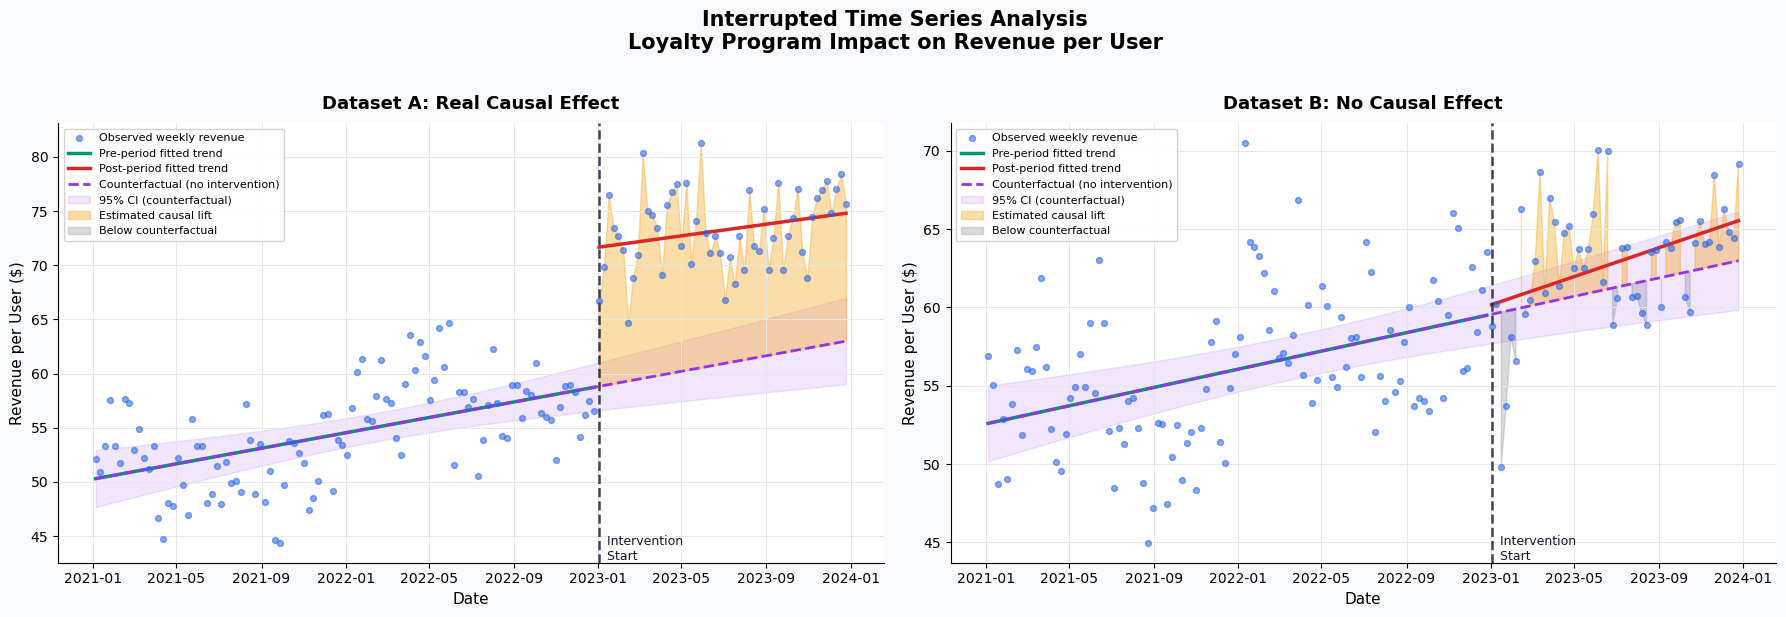

In [61]:
# =============================================================================
# SECTION 5: MAIN ITS CHART - BOTH DATASETS SIDE BY SIDE
# =============================================================================

def plot_its_main(df, result, title, ax):
    """
    Creates the main ITS visualization for one dataset.

    What this chart shows:
      - Blue dots: the actual observed weekly revenue per user over time
      - Green line: the model's fitted trend in the PRE period (before intervention)
      - Red line: the model's fitted trend in the POST period (after intervention)
      - Purple dashed line: the COUNTERFACTUAL - what the trend would have looked
        like if the intervention never happened (just the pre-period trend extended)
      - Purple shading: 95% confidence band around the counterfactual
      - Amber shading: the GAP between actual post-period data and counterfactual
        this is the estimated causal effect
      - Vertical dashed line: marks the exact moment the intervention started

    How to read it:
      - If the red line (post actual) is clearly above the purple line (counterfactual)
        and outside the shaded confidence band, there is statistical evidence
        of a causal effect
      - If the red line hugs the purple line and stays within the band, the
        intervention likely did not cause a change beyond what was already trending
    """
    n_pre  = (df["post"] == 0).sum()
    pre    = df[df["post"] == 0]
    post   = df[df["post"] == 1]

    # ── Raw data points ─────────────────────────────────────────────────────
    ax.scatter(df["date"], df["revenue_pu"],
               color=COLORS["actual"], s=18, alpha=0.55, zorder=3, label="Observed weekly revenue")

    # ── Pre-period fitted line ───────────────────────────────────────────────
    ax.plot(pre["date"], pre["fitted_actual"],
            color=COLORS["pre_fit"], lw=2.5, label="Pre-period fitted trend")

    # ── Post-period fitted line ──────────────────────────────────────────────
    ax.plot(post["date"], post["fitted_actual"],
            color=COLORS["post_fit"], lw=2.5, label="Post-period fitted trend")

    # ── Counterfactual line + confidence band ────────────────────────────────
    ax.plot(df["date"], df["counterfactual"],
            color=COLORS["counterfactual"], lw=2, ls="--", label="Counterfactual (no intervention)")
    ax.fill_between(df["date"], df["cf_lower"], df["cf_upper"],
                    color=COLORS["ci"], alpha=0.12, label="95% CI (counterfactual)")

    # ── Impact shading (gap between actual and counterfactual in post period) ─
    ax.fill_between(post["date"], post["revenue_pu"], post["counterfactual"],
                    where=(post["revenue_pu"] >= post["counterfactual"]),
                    color=COLORS["impact"], alpha=0.35, label="Estimated causal lift")
    ax.fill_between(post["date"], post["revenue_pu"], post["counterfactual"],
                    where=(post["revenue_pu"] <  post["counterfactual"]),
                    color=COLORS["neutral"], alpha=0.25, label="Below counterfactual")

    # ── Intervention vertical line ───────────────────────────────────────────
    ax.axvline(INTERVENTION_DATE, color="#111827", lw=1.8, ls="--", alpha=0.8)
    ax.text(INTERVENTION_DATE, ax.get_ylim()[0],
            "  Intervention\n  Start", va="bottom", fontsize=9, color="#111827")

    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue per User ($)")
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)


fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
fig.suptitle("Interrupted Time Series Analysis\nLoyalty Program Impact on Revenue per User",
             fontsize=15, fontweight="bold", y=1.02)

plot_its_main(df_effect,    result_effect,    "Dataset A: Real Causal Effect",  axes[0])
plot_its_main(df_no_effect, result_no_effect, "Dataset B: No Causal Effect",    axes[1])

plt.tight_layout()
plt.show()



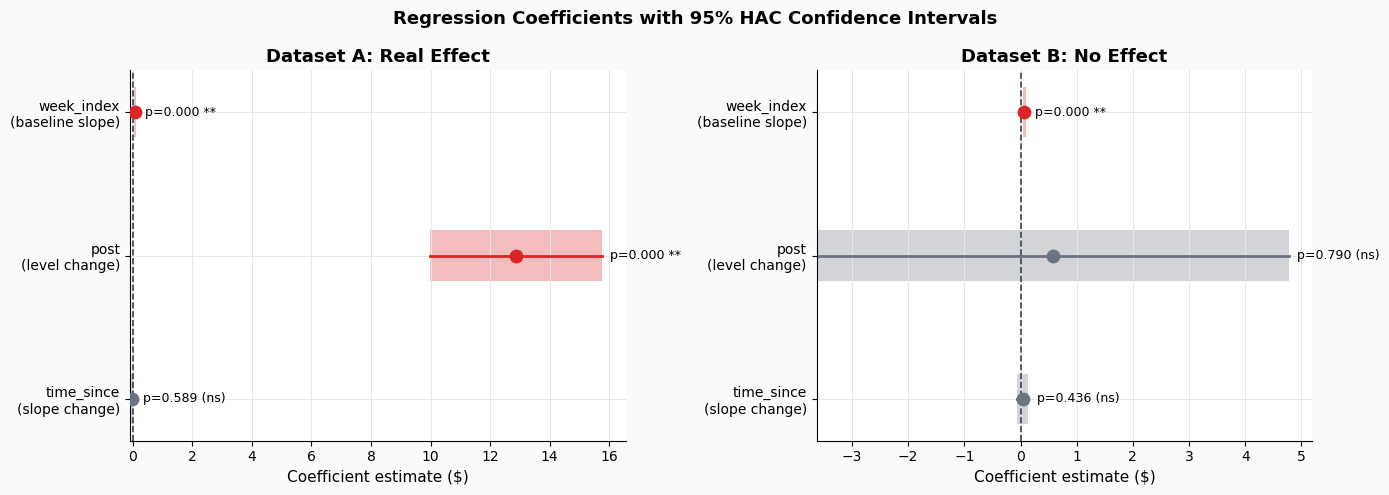

In [63]:
# =============================================================================
# SECTION 6: COEFFICIENT PLOT - WHAT DID THE MODEL ESTIMATE?
# =============================================================================

def plot_coefficients(result_a, result_b):
    """
    Side-by-side coefficient plot comparing the two datasets.

    What this chart shows:
      - Each row is one regression coefficient (level change or slope change)
      - The dot is the point estimate (the model's best guess of the effect size)
      - The horizontal bar is the 95% confidence interval
      - If the bar crosses zero, the effect is NOT statistically significant
      - If it stays entirely on one side of zero, the effect IS significant

    Why this matters:
      - For Dataset A we expect the 'post' (level) and 'time_since' (slope)
        coefficients to be positive and significant
      - For Dataset B we expect both to straddle zero (no real effect)
      - This is a standard way to present regression results to stakeholders
        without showing a raw table of numbers
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Regression Coefficients with 95% HAC Confidence Intervals",
                 fontsize=13, fontweight="bold")

    for ax, result, label in zip(
        axes,
        [result_a, result_b],
        ["Dataset A: Real Effect", "Dataset B: No Effect"]
    ):
        # Extract the three meaningful coefficients (skip the intercept)
        coef_names  = ["week_index\n(baseline slope)", "post\n(level change)", "time_since\n(slope change)"]
        coef_keys   = ["week_index", "post", "time_since"]
        coefs  = [result.params[k]    for k in coef_keys]
        ci_low = [result.conf_int().loc[k, 0] for k in coef_keys]
        ci_hi  = [result.conf_int().loc[k, 1] for k in coef_keys]
        pvals  = [result.pvalues[k]   for k in coef_keys]

        y_pos = np.arange(len(coef_keys))

        for i, (c, lo, hi, p) in enumerate(zip(coefs, ci_low, ci_hi, pvals)):
            color = COLORS["post_fit"] if p < 0.05 else COLORS["neutral"]
            ax.barh(y_pos[i], hi - lo, left=lo, height=0.35,
                    color=color, alpha=0.3)
            ax.plot([lo, hi], [y_pos[i], y_pos[i]], color=color, lw=2)
            ax.scatter(c, y_pos[i], color=color, s=80, zorder=5)
            sig_label = f"  p={p:.3f} {'**' if p < 0.01 else '*' if p < 0.05 else '(ns)'}"
            ax.text(hi + 0.01, y_pos[i], sig_label, va="center", fontsize=9)

        ax.axvline(0, color="#374151", lw=1.2, ls="--")
        ax.set_yticks(y_pos)
        ax.set_yticklabels(coef_names, fontsize=10)
        ax.set_xlabel("Coefficient estimate ($)")
        ax.set_title(label, fontweight="bold")
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


plot_coefficients(result_effect, result_no_effect)


In [67]:
'''
If the entire bar is to the right of zero: positive effect, and statistically significant at 5%. Colored red in the chart.
If the entire bar is to the left of zero: negative effect, statistically significant.
If the bar crosses zero: the effect is not statistically distinguishable from zero. Colored gray.
'''

'\nIf the entire bar is to the right of zero: positive effect, and statistically significant at 5%. Colored red in the chart.\nIf the entire bar is to the left of zero: negative effect, statistically significant.\nIf the bar crosses zero: the effect is not statistically distinguishable from zero. Colored gray.\n'

In [68]:
'''
Unlike ARIMA
in ITS, you are not claiming the raw series is stationary. 
You are claiming that after accounting for the trend (week_index), the intervention (post), and the slope change (time_since), 
the remaining unexplained variation (the residuals) behaves like stationary noise. The residuals are what the model could not explain
'''

'\nUnlike ARIMA\nin ITS, you are not claiming the raw series is stationary. \nYou are claiming that after accounting for the trend (week_index), the intervention (post), and the slope change (time_since), \nthe remaining unexplained variation (the residuals) behaves like stationary noise. The residuals are what the model could not explain\n'

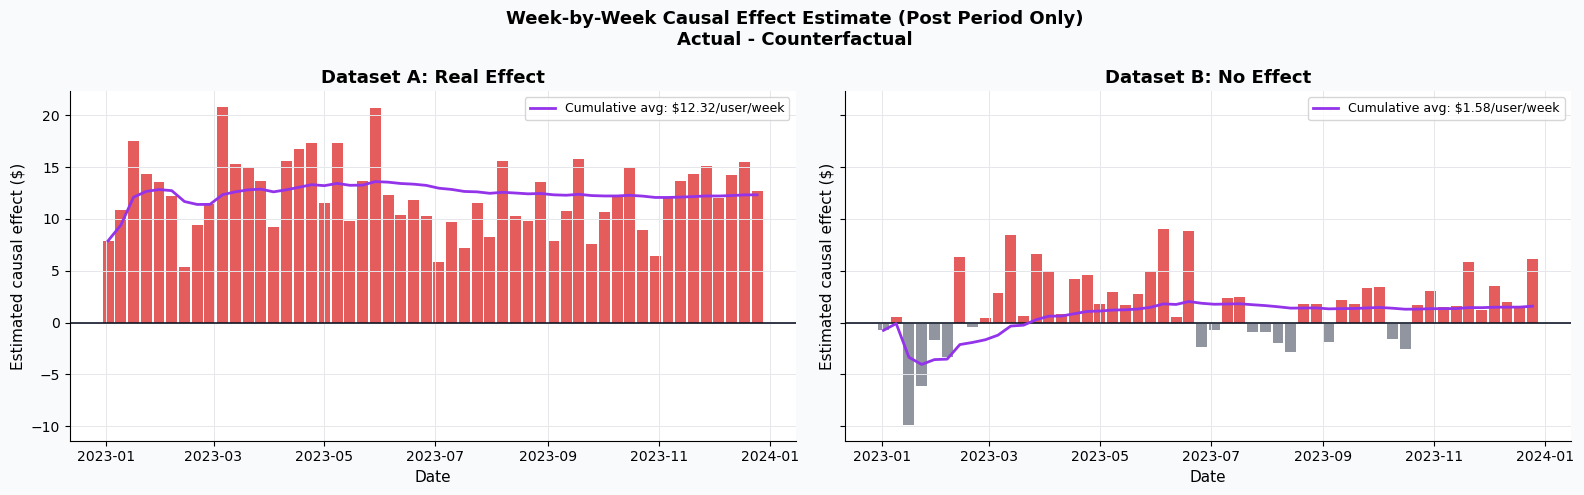

In [42]:
# =============================================================================
# SECTION 7: CAUSAL EFFECT OVER TIME CHART
# =============================================================================

def plot_causal_effect_over_time(df_a, df_b):
    """
    Shows the week-by-week estimated causal effect = actual minus counterfactual.

    What this chart shows (post period only):
      - Each bar is one week in the post period
      - Bar height = observed revenue minus what the counterfactual predicted
      - If bars are consistently positive and growing over time -> real effect
      - If bars hover around zero and are noisy -> no effect

    This is the most intuitive way to show stakeholders the magnitude and
    consistency of a causal effect over time. A real effect tends to show
    a pattern; noise tends to show random positive/negative fluctuations.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    fig.suptitle("Week-by-Week Causal Effect Estimate (Post Period Only)\nActual - Counterfactual",
                 fontsize=13, fontweight="bold")

    for ax, df, label in zip(
        axes,
        [df_a, df_b],
        ["Dataset A: Real Effect", "Dataset B: No Effect"]
    ):
        post_df = df[df["post"] == 1].copy()
        colors  = [COLORS["post_fit"] if v >= 0 else COLORS["neutral"]
                   for v in post_df["causal_effect"]]

        ax.bar(post_df["date"], post_df["causal_effect"],
               color=colors, alpha=0.75, width=6)
        ax.axhline(0, color="#111827", lw=1.2)

        # Cumulative average effect line
        cum_avg = post_df["causal_effect"].expanding().mean()
        ax.plot(post_df["date"], cum_avg,
                color=COLORS["counterfactual"], lw=2, ls="-",
                label=f"Cumulative avg: ${cum_avg.iloc[-1]:.2f}/user/week")

        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Date")
        ax.set_ylabel("Estimated causal effect ($)")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


plot_causal_effect_over_time(df_effect, df_no_effect)


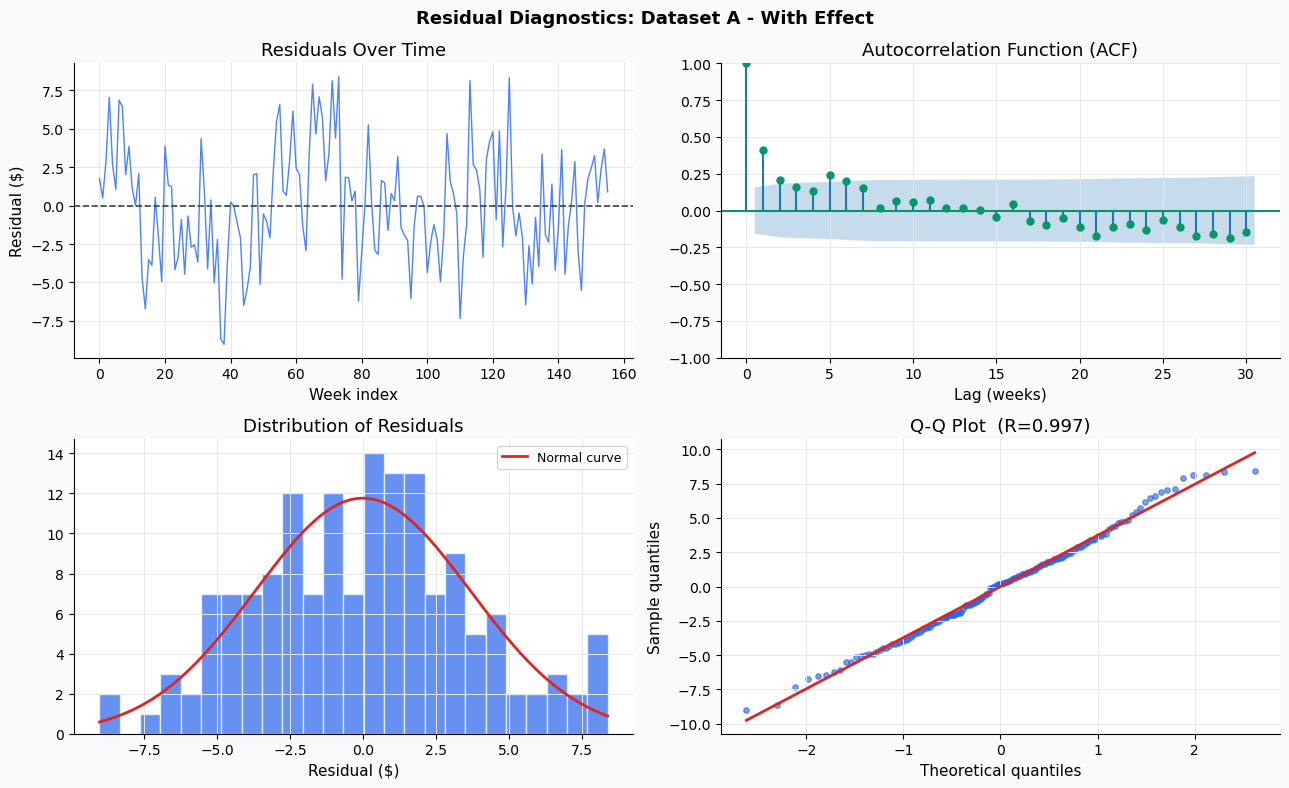

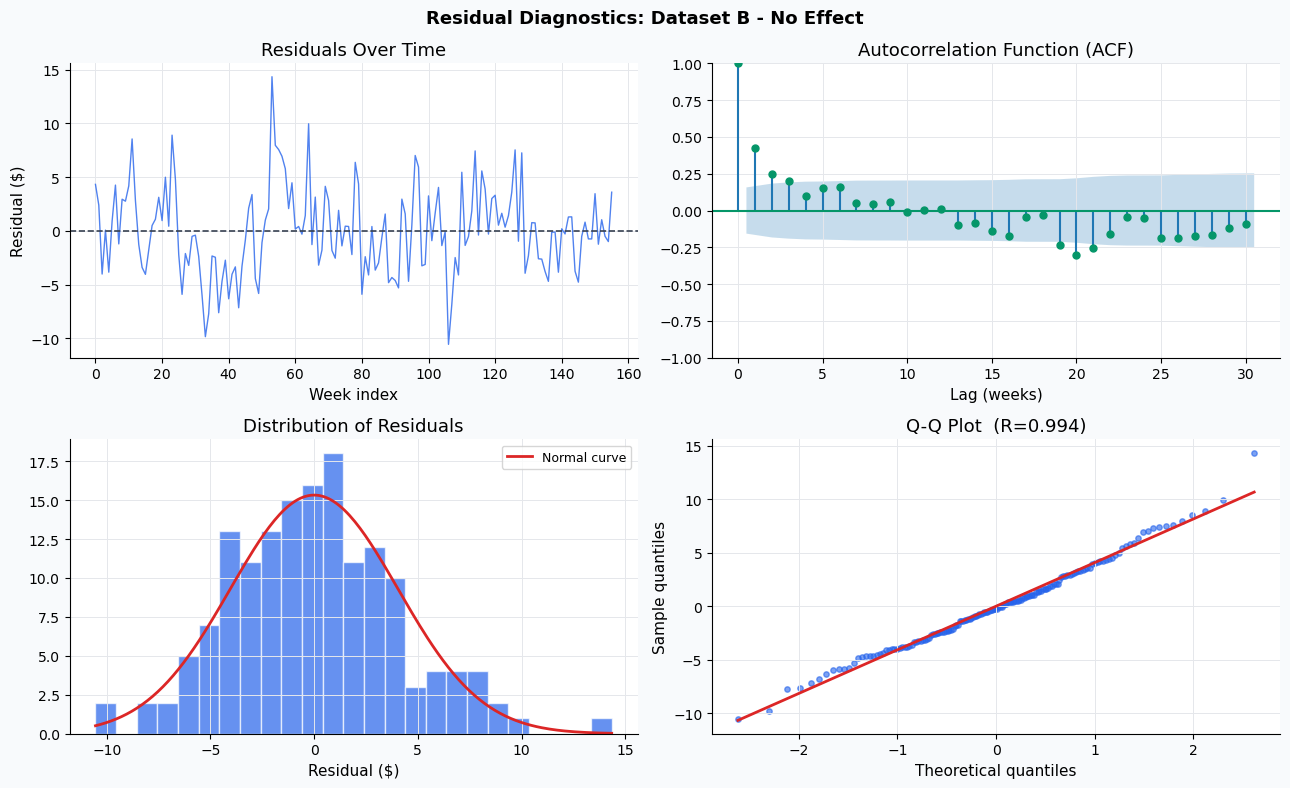

In [69]:
# =============================================================================
# SECTION 8: RESIDUAL DIAGNOSTICS CHART
# =============================================================================

def plot_residual_diagnostics(result_a, result_b):
    """
    Four-panel diagnostic chart for each dataset's model residuals.

    What each panel shows:

    Panel 1 - Residuals over time:
      We want residuals to look like random noise around zero with no obvious
      pattern. If we see a systematic wave or trend, the model is missing
      something (maybe a covariate or a lagged term).

    Panel 2 - ACF (Autocorrelation Function):
      Shows correlation of residuals with their own lagged versions.
      - Bars within the blue confidence band -> residuals are not autocorrelated (good)
      - Bars outside the band (especially at lag 1, 2, 3) -> autocorrelation remains,
        meaning our model's standard errors may still be underestimated even with HAC
        (consider adding lagged outcome as a predictor)

    Panel 3 - Histogram of residuals:
      Should look roughly bell-shaped and centered on zero.
      Heavy tails or skew indicate non-normality (less critical with HAC, but worth knowing).

    Panel 4 - Q-Q plot (Quantile-Quantile):
      Plots residual quantiles against theoretical normal quantiles.
      Points lying close to the diagonal line = residuals are approximately normal.
      Systematic S-curves or heavy tails signal non-normality.
    """
    for result, label in [(result_a, "Dataset A - With Effect"),
                           (result_b, "Dataset B - No Effect")]:

        resid = result.resid.values
        fig, axes = plt.subplots(2, 2, figsize=(13, 8))
        fig.suptitle(f"Residual Diagnostics: {label}", fontsize=13, fontweight="bold")

        # Panel 1: Residuals over time
        ax = axes[0, 0]
        ax.plot(resid, color=COLORS["actual"], lw=1, alpha=0.8)
        ax.axhline(0, color="#374151", lw=1.2, ls="--")
        ax.set_title("Residuals Over Time")
        ax.set_xlabel("Week index")
        ax.set_ylabel("Residual ($)")

        # Panel 2: ACF plot
        ax = axes[0, 1]
        plot_acf(resid, lags=30, ax=ax, color=COLORS["pre_fit"], alpha=0.05)
        ax.set_title("Autocorrelation Function (ACF)")
        ax.set_xlabel("Lag (weeks)")

        # Panel 3: Histogram
        ax = axes[1, 0]
        ax.hist(resid, bins=25, color=COLORS["actual"], alpha=0.7, edgecolor="white")
        # Overlay a fitted normal curve
        x_range = np.linspace(resid.min(), resid.max(), 200)
        ax.plot(x_range,
                stats.norm.pdf(x_range, resid.mean(), resid.std()) * len(resid) * (resid.max() - resid.min()) / 25,
                color=COLORS["post_fit"], lw=2, label="Normal curve")
        ax.set_title("Distribution of Residuals")
        ax.set_xlabel("Residual ($)")
        ax.legend(fontsize=9)

        # Panel 4: Q-Q plot
        ax = axes[1, 1]
        (osm, osr), (slope, intercept, r) = stats.probplot(resid, dist="norm")
        ax.scatter(osm, osr, color=COLORS["actual"], s=15, alpha=0.6)
        ax.plot(osm, slope * np.array(osm) + intercept, color=COLORS["post_fit"], lw=2)
        ax.set_title(f"Q-Q Plot  (R={r:.3f})")
        ax.set_xlabel("Theoretical quantiles")
        ax.set_ylabel("Sample quantiles")

        plt.tight_layout()
        fname = f"/mnt/user-data/outputs/its_04_diagnostics_{'A' if 'With' in label else 'B'}.png"
        plt.show()


plot_residual_diagnostics(result_effect, result_no_effect)


In [71]:
# ACF INTERPRETATION NOTE
# The blue shaded band in the ACF plot is the 95% confidence band.
# It represents the range of autocorrelation values we would expect to see
# purely by chance if the residuals were truly white noise (no real pattern).
# Any bar that sticks OUTSIDE this band means the autocorrelation at that lag
# is real and not just random fluctuation.
#
# In Dataset A, lag-1 sits at ~0.42, well outside the band. This means:
# after the model explains trend + intervention, this week's leftover error
# still predicts next week's leftover error with 42% correlation.
# This is the AR(1) noise structure we baked into the data generation step.
# Smaller spikes at lags 5-7 reflect the annual seasonal sine wave
# in the data (52-week cycle shows up at sub-multiples like 13, 6-7 weeks).
#
# The HAC (Newey-West) standard errors partially correct for this, but
# with a spike this large at lag-1, it is doing damage control rather than
# a clean fix. Coefficient estimates (betas) are still unbiased. However,
# confidence intervals are slightly too narrow and p-values slightly too
# optimistic. In a borderline result (p ~ 0.04) this could flip your conclusion.
#
# THE FIX
# Add the lagged outcome as a covariate. This lets the model explicitly
# absorb the week-to-week carryover, so the REMAINING residuals become
# closer to white noise and HAC does a proper job.
#
# Step 1: create the lag column (do this right after generate_its_data)
#     df["revenue_lag1"] = df["revenue_pu"].shift(1)
#     df = df.dropna()   # drops the first row where lag1 is NaN
#
# Step 2: update fit_its_model to include it
#     X = sm.add_constant(df[["week_index", "post", "time_since", "revenue_lag1"]])
#
# Step 3: rerun the ACF diagnostic on the new residuals and check
#         whether the lag-1 spike drops inside the confidence band.
#         If it does, the fix worked. If structure remains, consider
#         ARIMA-ITS using statsmodels SARIMAX with post and time_since
#         passed in as exog regressors, and the AR/MA terms handling
#         the residual autocorrelation explicitly.
#
# Sensitivity check to report: run both models (with and without lag1).
# If the post coefficient barely moves, autocorrelation was not biasing
# the estimate. If it shifts substantially, the original model was
# partially attributing autocorrelation artifacts to the intervention.

In [66]:
'''
In ARIMA, you use ADF to decide the order of differencing d.
The logic is identical: you're testing whether the series needs to be differenced to become stationary.
In ITS, you're applying ADF to the residuals of your regression rather than the raw series
asking whether your model left behind a non-stationary error process.
'''

"\nIn ARIMA, you use ADF to decide the order of differencing d.\nThe logic is identical: you're testing whether the series needs to be differenced to become stationary.\nIn ITS, you're applying ADF to the residuals of your regression rather than the raw series\nasking whether your model left behind a non-stationary error process.\n"

In [45]:
# =============================================================================
# SECTION 9: RESULTS SUMMARY
# =============================================================================

def print_results_summary(result, df, label):
    """
    Prints a clean, executive-level summary of ITS findings.

    This is the kind of output a DS would present to a VP or GM:
      - The estimated immediate lift at intervention launch
      - The estimated change in weekly growth rate
      - The cumulative revenue impact over the post period
      - Whether each finding is statistically significant
      - A plain-language interpretation

    Everything is expressed in business terms (dollars, not coefficient values)
    so it is directly actionable.
    """
    params = result.params
    pvals  = result.pvalues
    ci     = result.conf_int()

    level_change = params["post"]
    slope_change = params["time_since"]
    p_level      = pvals["post"]
    p_slope      = pvals["time_since"]

    post_df       = df[df["post"] == 1]
    avg_effect_pw = post_df["causal_effect"].mean()
    total_weeks   = len(post_df)

    print(f"\n{'='*65}")
    print(f"  RESULTS SUMMARY: {label}")
    print(f"{'='*65}")
    print(f"  Intervention date       : {INTERVENTION_DATE.date()}")
    print(f"  Post-period weeks       : {total_weeks}")
    print(f"\n  -- Model Estimates --")
    print(f"  Level change (post)     : ${level_change:+.2f}/user  "
          f"  [95% CI: ${ci.loc['post',0]:.2f} to ${ci.loc['post',1]:.2f}]  "
          f"  p={p_level:.4f} {'SIGNIFICANT' if p_level < 0.05 else 'not significant'}")
    print(f"  Slope change (time_since): ${slope_change:+.4f}/user/week  "
          f"  [95% CI: ${ci.loc['time_since',0]:.4f} to ${ci.loc['time_since',1]:.4f}]  "
          f"  p={p_slope:.4f} {'SIGNIFICANT' if p_slope < 0.05 else 'not significant'}")
    print(f"\n  -- Business Impact --")
    print(f"  Avg causal effect       : ${avg_effect_pw:+.2f}/user/week (actual - counterfactual)")
    print(f"\n  -- Interpretation --")
    if p_level < 0.05 or p_slope < 0.05:
        print(f"  The loyalty program is associated with a statistically significant")
        print(f"  change in revenue per user. Evidence supports a CAUSAL EFFECT.")
    else:
        print(f"  Neither the level change nor slope change is statistically significant.")
        print(f"  The post-period trend is consistent with the pre-period trajectory.")
        print(f"  Evidence does NOT support a causal effect from the loyalty program.")
    print(f"{'='*65}\n")


print_results_summary(result_effect,    df_effect,    "Dataset A - With Causal Effect")
print_results_summary(result_no_effect, df_no_effect, "Dataset B - No Causal Effect")



  RESULTS SUMMARY: Dataset A - With Causal Effect
  Intervention date       : 2023-01-02
  Post-period weeks       : 52

  -- Model Estimates --
  Level change (post)     : $+12.86/user    [95% CI: $9.97 to $15.76]    p=0.0000 SIGNIFICANT
  Slope change (time_since): $-0.0205/user/week    [95% CI: $-0.0949 to $0.0539]    p=0.5894 not significant

  -- Business Impact --
  Avg causal effect       : $+12.32/user/week (actual - counterfactual)

  -- Interpretation --
  The loyalty program is associated with a statistically significant
  change in revenue per user. Evidence supports a CAUSAL EFFECT.


  RESULTS SUMMARY: Dataset B - No Causal Effect
  Intervention date       : 2023-01-02
  Post-period weeks       : 52

  -- Model Estimates --
  Level change (post)     : $+0.57/user    [95% CI: $-3.63 to $4.77]    p=0.7902 not significant
  Slope change (time_since): $+0.0382/user/week    [95% CI: $-0.0578 to $0.1342]    p=0.4357 not significant

  -- Business Impact --
  Avg causal effect 

In [46]:
# =============================================================================
# SECTION 10: ASSUMPTIONS CHECKLIST (DS Knowledge)
# =============================================================================

print("""
======================================================================
ITS ASSUMPTIONS - WHAT EVERY DS MUST KNOW
======================================================================

1. NO CONCURRENT EVENTS
   The intervention must be the ONLY notable thing that changed at
   that time point. If a competitor also launched a promotion on the
   same date, we cannot isolate the loyalty program's effect.
   Check: interviews with the business, event logs, external data.

2. NO SELECTION INTO TREATMENT
   In classic ITS, everyone gets the intervention (no control group).
   The key threat is if the population composition changed right at
   the intervention (e.g., a big new user acquisition push launched
   simultaneously). That would confound the level change estimate.

3. PRE-PERIOD TREND CORRECTLY SPECIFIED
   We assume the pre-period trend is a reasonable proxy for what
   would have happened post-intervention. If the pre-period had
   unusual trends (e.g., a one-time spike), the counterfactual
   will be wrong.
   Check: plot pre-period carefully, test alternative functional forms.

4. STATIONARITY OF RESIDUALS
   ITS regression assumes residuals don't have a unit root.
   Test: Augmented Dickey-Fuller on residuals.

5. AUTOCORRELATION IS HANDLED
   Weekly/monthly data almost always has correlated residuals.
   We use Newey-West (HAC) standard errors to get valid inference.
   This is NON-OPTIONAL for time series regression.

6. INTERVENTION IS EXOGENOUS
   The intervention timing must not have been chosen because of
   the outcome (e.g., "we launched because revenue was already rising").
   If timing was endogenous, ITS will overstate the effect.

7. NO CARRYOVER / ANTICIPATION EFFECTS
   Individuals should not change behavior in ANTICIPATION of the
   intervention. If users knew the loyalty program was coming and
   saved purchases, the pre-period artificially deflates, making the
   post-period jump look larger than it really is.

======================================================================
EXTENSIONS TO KNOW
======================================================================

* Segmented regression with control series (Comparative ITS / CITS):
  Use a parallel control group (e.g., users in a market where the
  program did NOT launch) to difference out secular trends.
  This is stronger causal evidence than single-series ITS.

* ARIMA-ITS: Explicitly model residual autocorrelation in the error
  structure using ARIMA(p,d,q) instead of relying solely on HAC SEs.

* Bayesian Structural Time Series (CausalImpact by Google):
  Uses a state-space model to build the counterfactual. More flexible
  for complex seasonal patterns. Available in Python via tfcausalimpact.

* Non-linear ITS: If the intervention effect fades or grows non-linearly
  (e.g., habituation), add polynomial or spline terms for time_since.

* Power analysis for ITS: Use pre-period residual variance and
  autocorrelation to estimate the minimum detectable effect before
  launching an intervention.

======================================================================
""")


ITS ASSUMPTIONS - WHAT EVERY STAFF DS MUST KNOW

1. NO CONCURRENT EVENTS
   The intervention must be the ONLY notable thing that changed at
   that time point. If a competitor also launched a promotion on the
   same date, we cannot isolate the loyalty program's effect.
   Check: interviews with the business, event logs, external data.

2. NO SELECTION INTO TREATMENT
   In classic ITS, everyone gets the intervention (no control group).
   The key threat is if the population composition changed right at
   the intervention (e.g., a big new user acquisition push launched
   simultaneously). That would confound the level change estimate.

3. PRE-PERIOD TREND CORRECTLY SPECIFIED
   We assume the pre-period trend is a reasonable proxy for what
   would have happened post-intervention. If the pre-period had
   unusual trends (e.g., a one-time spike), the counterfactual
   will be wrong.
   Check: plot pre-period carefully, test alternative functional forms.

4. STATIONARITY OF RESIDUALS
   